In [1]:
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from joblib import Parallel, delayed
import os

import src.utils as utils
from src.model import Nonneg_dyn_dag_learning
from src.baselines import Dynotears


PATH = './results/lags/'
SAVE = True 
SEED = 10
N_CPUS = os.cpu_count()
np.random.seed(SEED)

## Auxiliary functions

In [2]:
def run_lags_exp(g, data_p, N_lags, exps, thr=.075, verb=False):
    shd, fs_W, err_W, fs_A, err_A, acyc, runtime, dag_count = [np.zeros((len(N_lags), len(exps)))  for _ in range(8)]

    for i, n_lags in enumerate(N_lags):
        if verb and (g % N_CPUS == 0):
            print(f'Graph: {g+1}, lags: {n_lags}')

        # Create data
        data_p_aux = data_p.copy()
        data_p_aux['n_lags'] = n_lags
        W_true, _, A_true, _, X, Y = utils.simulate_svar(**data_p_aux)

        N = data_p['n_nodes']

        W_true_bin = utils.to_bin(W_true, thr)
        A_true_bin = utils.to_bin(A_true, thr)
        norm_W_true = np.linalg.norm(W_true)
        norm_A_true = np.linalg.norm(A_true)
        
        for j, exp in enumerate(exps):
            arg_aux = exp['args'].copy()
            if 'adapt_lamb' in exp.keys() and exp['adapt_lamb']:
                arg_aux['lamb_W'] = utils.get_lamb_value(N, data_p['n_samples'], arg_aux['lamb_W'])
                arg_aux['lamb_A'] = utils.get_lamb_value(N*n_lags, data_p['n_samples'], arg_aux['lamb_A'])

            model = exp['model'](**exp['init']) if 'init' in exp.keys() else exp['model']()
            t_init = perf_counter()
            model.fit(X, Y, **arg_aux)
            t_end = perf_counter()
                
            W_est = model.W_est
            A_est = model.A_est

            if np.isnan(W_est).any() or np.isnan(A_est).any():
                W_est = np.zeros_like(W_est)
                A_est = np.zeros_like(A_est)
                W_est_bin = np.zeros_like(W_est)
                A_est_bin = np.zeros_like(A_est)
            else:
                W_est_bin = utils.to_bin(W_est, thr)
                A_est_bin = utils.to_bin(A_est, thr)
            
            shd[i,j], _, _ = utils.count_accuracy(W_true_bin, W_est_bin)
            fs_W[i,j] = f1_score(W_true_bin.flatten(), W_est_bin.flatten())
            fs_A[i,j] = f1_score(A_true_bin.flatten(), A_est_bin.flatten())
            err_W[i,j] = utils.compute_norm_sq_err(W_true, W_est, norm_W_true)
            err_A[i,j] = utils.compute_norm_sq_err(A_true, A_est, norm_A_true)
            acyc[i,j] = model.dagness(W_est) if hasattr(model, 'dagness') else -1
            runtime[i,j] = t_end - t_init
            dag_count[i,j] += 1 if utils.is_dag(W_est_bin) else 0
        
            # normalizing by the size of the graph
            shd[i,j] /= N

            if verb and (g % N_CPUS == 0):
                print(f'\t-{exp["leg"]}: shd {shd[i,j]}  -  err W: {err_W[i,j]:.3f}  -  '
                      f'err A: {err_A[i,j]:.3f}  - time: {runtime[i,j]:.3f}')

    return shd, fs_W, fs_A, err_W, err_A, acyc, runtime, dag_count

## Evaluated models

In [3]:
n_dags = 50
N_lags = np.array( [1, 2, 3, 4] )

Exps = [
    {'model': Nonneg_dyn_dag_learning, 'init': {'acyclicity': 'logdet', 'primal_opt': 'fista', 'restart': True},
     'args': {'stepsize': 5e-4, 'alpha_0': 1, 'rho_0': .05, 's': 1, 'lamb_W': .5, 'lamb_A': 1,
              'iters_in': 5000, 'iters_out': 10, 'beta': 10}, 
     'adapt_lamb': True, 'fmt': '-o', 'leg': 'APGD'},

    {'model': Nonneg_dyn_dag_learning, 'init': {'acyclicity': 'logdet', 'primal_opt': 'adam', 'restart': True},
     'args': {'stepsize': 3e-4, 'alpha_0': 1, 'rho_0': .05, 's': 1, 'lamb_W': .5, 'lamb_A': 1,
              'iters_in': 10000, 'iters_out': 10, 'beta': 5}, 
     'adapt_lamb': True, 'fmt': '--o', 'leg': 'Adam'},

    {'model': Nonneg_dyn_dag_learning, 'init': {'acyclicity': 'logdet', 'primal_opt': 'sca-adam'},
     'args': {'stepsize': 5e-4, 'alpha_0': 1, 'rho_0': .1, 's': 1, 'lamb_W': .5, 'lamb_A': .05,
              'iters_in': 1000, 'iters_out': 20, 'beta': 5}, 
     'adapt_lamb': True, 'fmt': ':o', 'leg': 'SCA-ADAM'},

    # Baselines
    {'model': Dynotears, 'init': {}, 'args': {}, 'adapt_lamb': False, 'fmt': '--x', 'leg': 'DYNOTEARS'},
    # {'model': Dynotears, 'init': {}, 'args': {}, 'adapt_lamb': True, 'args': {'lamb_W': 3.5, 'lamb_A': 3.3,},
    #  'fmt': '--x', 'leg': 'DYNOTEARS-lamb'},
]

## Experiments

### T=5000

In [4]:
thr = .075
verb = True
N = 50
data_params = {
    'n_nodes': N,
    'dag_graph_type': 'er',
    'dag_edges': 4*N,     # mean degree
    'dag_w_range': (.1, .5),
    'lag_graph_type': 'er',
    'er_edges': N,      # mean degree
    'lag_w_range': (.1, .4),
    'exp_decay': 1.5,
    'n_samples': 5000,
    'noise_type': 'normal',
    'var': 1
}

print('CPUs employed:', N_CPUS)

t_init = perf_counter()
results = Parallel(n_jobs=N_CPUS)(delayed(run_lags_exp)
                                  (g, data_params, N_lags, Exps, thr, verb) for g in range(n_dags))

t_end = perf_counter()
print(f'----- Solved in {(t_end-t_init)/60:.3f} minutes -----')

shd, fs_W, fs_A, err_W, err_A, acyc, runtime, dag_count = zip(*results)

CPUs employed: 168
Graph: 1, lags: 1
	-APGD: shd 0.02  -  err W: 0.004  -  err A: 0.004  - time: 3.432
	-Adam: shd 0.04  -  err W: 0.007  -  err A: 0.004  - time: 4.516
	-SCA-ADAM: shd 0.44  -  err W: 0.063  -  err A: 0.159  - time: 3.894
	-DYNOTEARS: shd 0.64  -  err W: 0.065  -  err A: 0.019  - time: 496.515
Graph: 1, lags: 2
	-APGD: shd 0.0  -  err W: 0.003  -  err A: 0.007  - time: 3.872
	-Adam: shd 0.0  -  err W: 0.003  -  err A: 0.007  - time: 4.476
	-SCA-ADAM: shd 3.18  -  err W: 0.589  -  err A: 0.452  - time: 1.210
	-DYNOTEARS: shd 0.58  -  err W: 0.071  -  err A: 0.047  - time: 136.668
Graph: 1, lags: 3
	-APGD: shd 0.06  -  err W: 0.202  -  err A: 0.015  - time: 4.210
	-Adam: shd 0.02  -  err W: 0.004  -  err A: 0.015  - time: 8.986
	-SCA-ADAM: shd 3.98  -  err W: 1.650  -  err A: 0.720  - time: 1.497
	-DYNOTEARS: shd 0.6  -  err W: 0.060  -  err A: 0.084  - time: 694.928
Graph: 1, lags: 4
	-APGD: shd 0.04  -  err W: 0.003  -  err A: 0.023  - time: 13.292
	-Adam: shd 0.04  - 

SAVED in file: ./results/lags/samples_50N_4


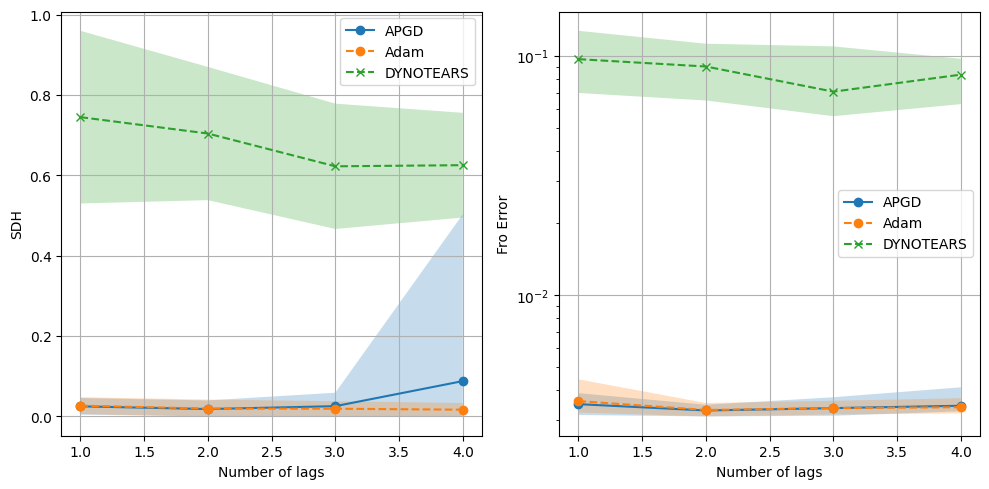

In [5]:
if SAVE:
    file_name = PATH + f'samples_{N}N_{int(data_params["dag_edges"]/N)}'
    np.savez(file_name, shd=shd, fs_W=fs_W, err_W=err_W, fs_A=fs_A, err_A=err_A,
             acyc=acyc, runtime=runtime, dag_count=dag_count, exps=Exps, xvals=N_lags)

    print('SAVED in file:', file_name)

    # agg_error = np.median(err, axis=0)
    # utils.data_to_csv(f'{PATH}samples_err_med.csv', Exps, N_samples, agg_error)
    # prctile25 = np.percentile(err, 25, axis=0)
    # utils.data_to_csv(f'{PATH}samples_err_prctile25.csv', Exps, N_samples, prctile25)
    # prctile75 = np.percentile(err, 75, axis=0)
    # utils.data_to_csv(f'{PATH}samples_err_prctile75.csv', Exps, N_samples, prctile75)

    # agg_shd = np.mean(err, axis=0)
    # utils.data_to_csv(f'{PATH}samples_shd_mean.csv', Exps, N_samples, agg_shd)
    # std_shd = np.std(err, axis=0)
    # utils.data_to_csv(f'{PATH}samples_shd_std.csv', Exps, N_samples, std_shd)

skip = [2]  # [1, 4]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_data(axes[0], shd, Exps, N_lags, 'Number of lags', 'SDH', skip,
                agg='mean', deviation='std', alpha=0.25,plot_func='plot')
utils.plot_data(axes[1], err_W, Exps, N_lags, 'Number of lags', 'Fro Error', skip,
                agg='median', deviation='prctile', alpha=0.25, plot_func='semilogy')
plt.tight_layout()

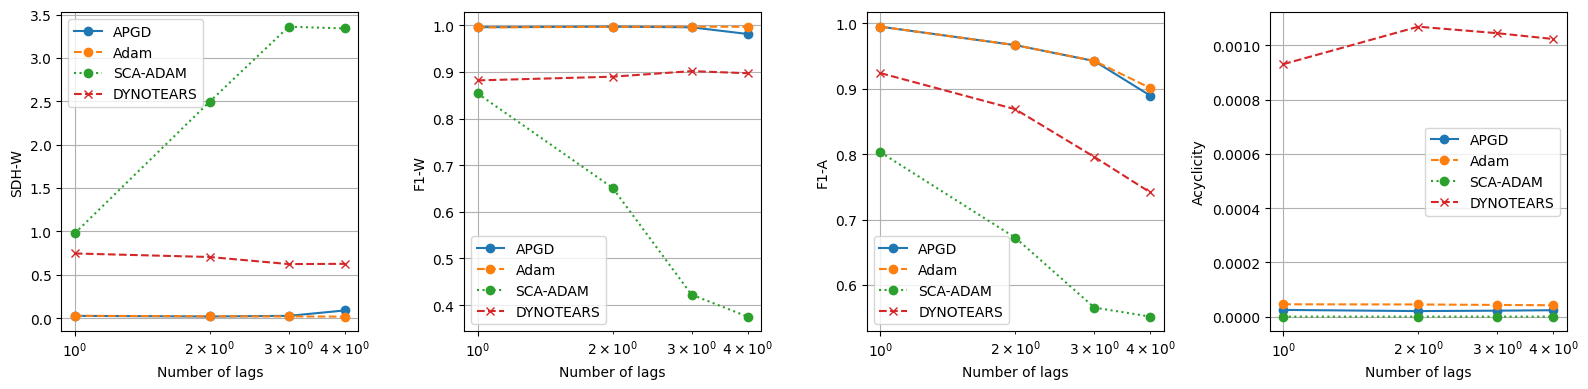

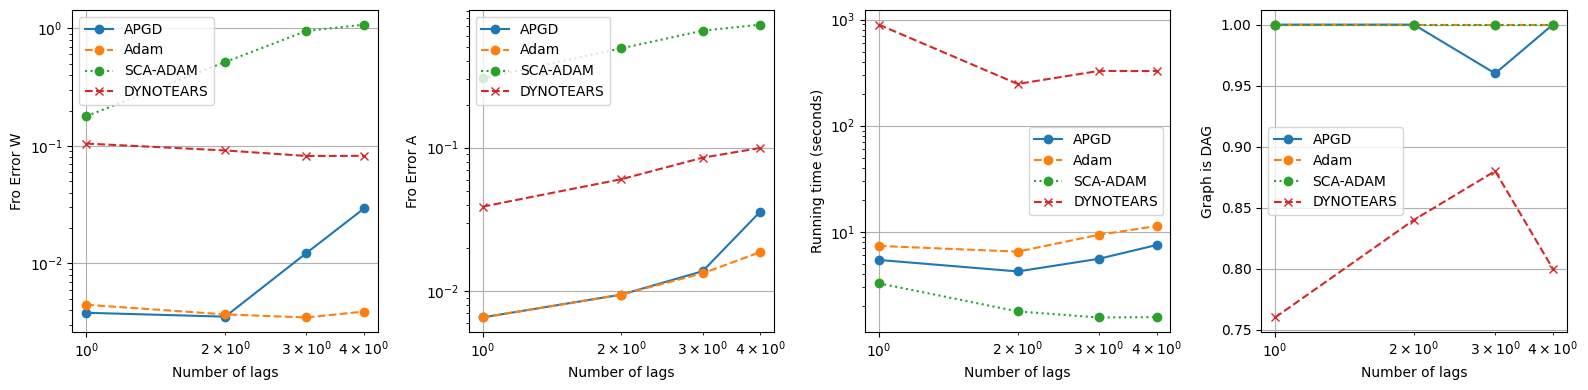

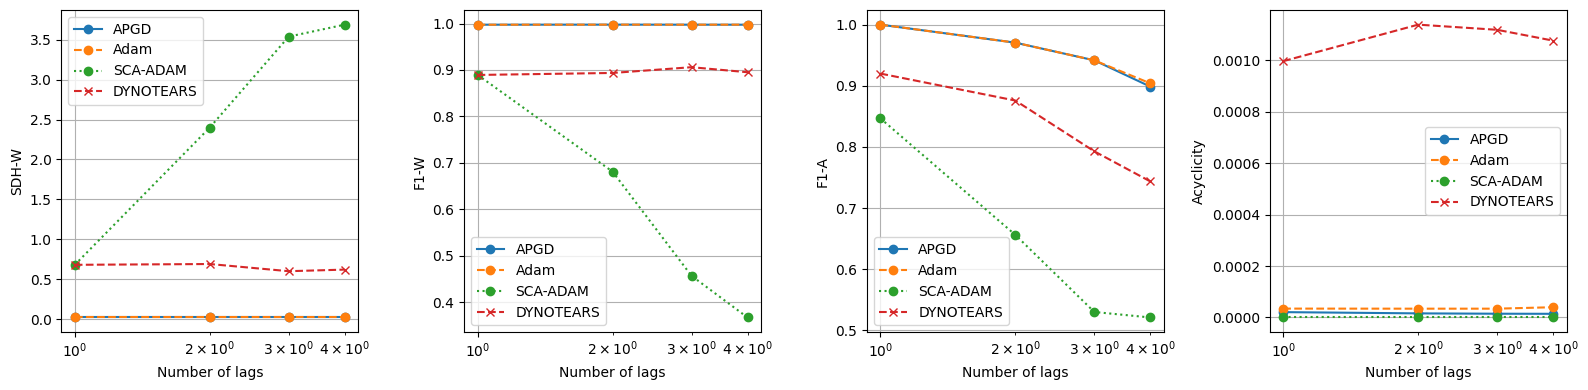

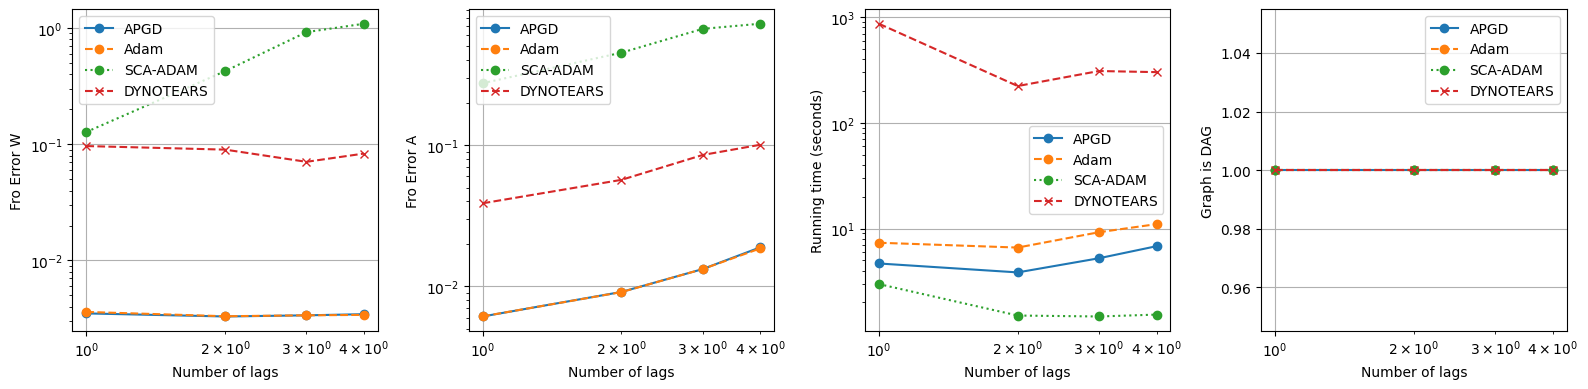

In [6]:
skip = [] # [2]
utils.plot_all_metrics(shd, fs_W, err_W, fs_A, err_A, acyc, runtime, dag_count, N_lags, Exps,
                 skip_idx=skip, agg='mean', xlabel='Number of lags')
utils.plot_all_metrics(shd, fs_W, err_W, fs_A, err_A, acyc, runtime, dag_count, N_lags, Exps,
                 skip_idx=skip, agg='median', xlabel='Number of lags')